Dataset Overview:
Dataset shape: (300, 5)

First 5 rows:


,customer_id,number_of_bots_created,conversation_length,active_days,features_used
0,1,1,39.575151,9,2
1,2,2,62.779268,7,2
2,3,0,47.389727,8,2
3,4,0,51.349847,2,2
4,5,3,54.125704,7,1


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             300 non-null    int64  
 1   number_of_bots_created  300 non-null    int32  
 2   conversation_length     300 non-null    float64
 3   active_days             300 non-null    int32  
 4   features_used           300 non-null    int32  
dtypes: float64(1), int32(3), int64(1)
memory usage: 8.3 KB
None

Descriptive Statistics:
       customer_id  number_of_bots_created  conversation_length  active_days  \
count   300.000000              300.000000           300.000000   300.000000   
mean    150.500000                7.090000           200.956581    27.446667   
std      86.746758                6.686124           152.792052    24.915788   
min       1.000000                0.000000            15.191912     1.000000   
25%      75.75

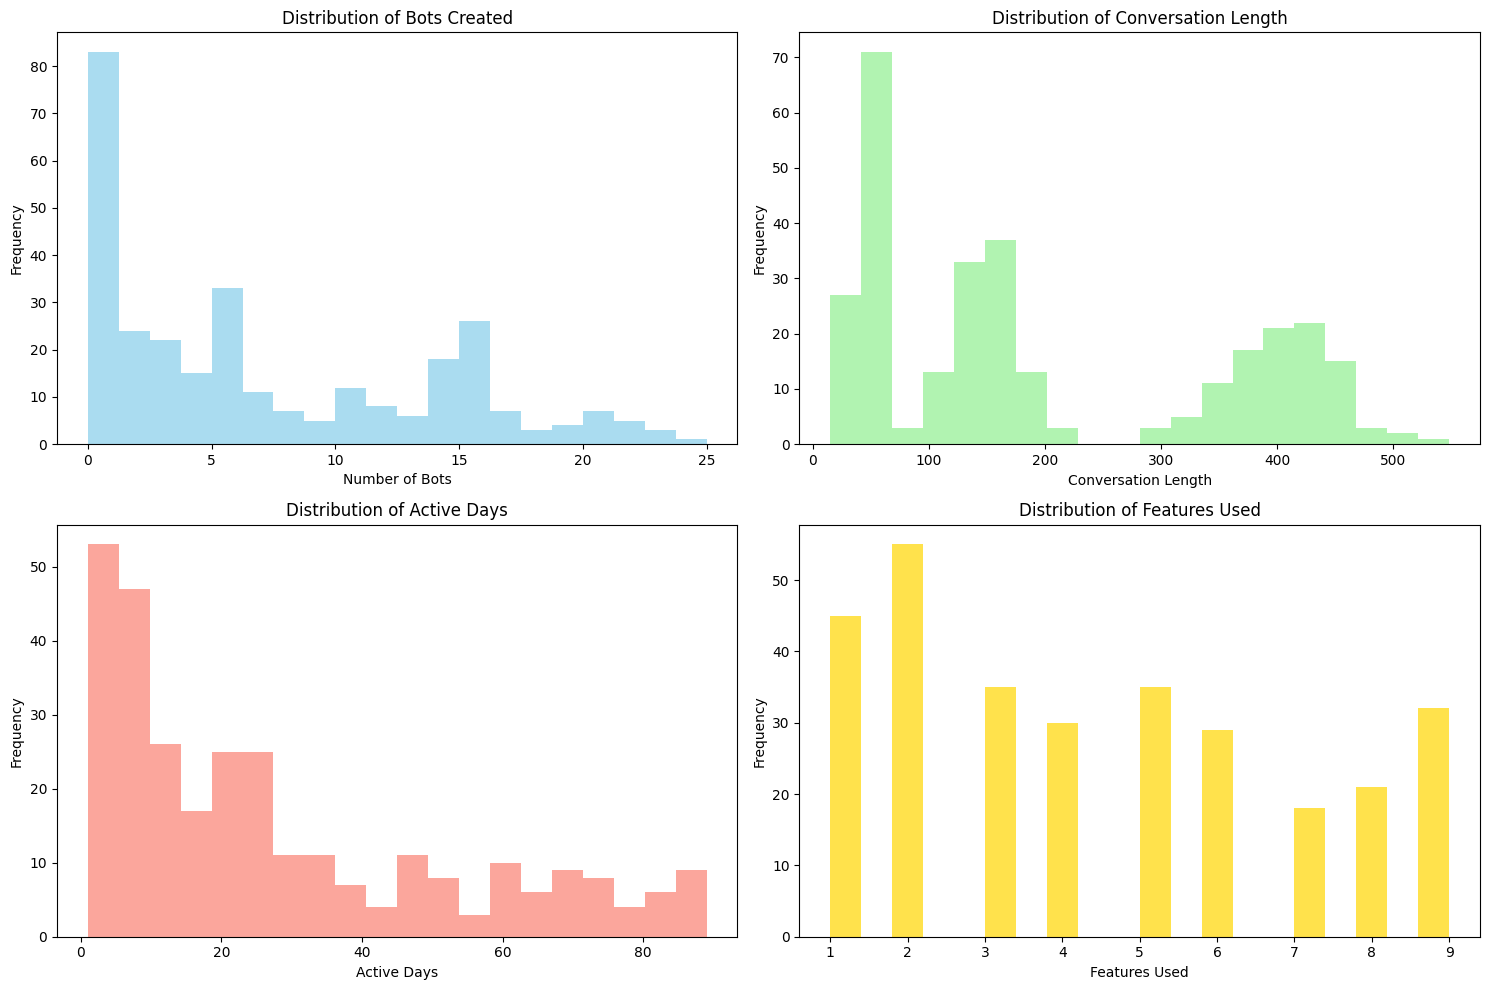

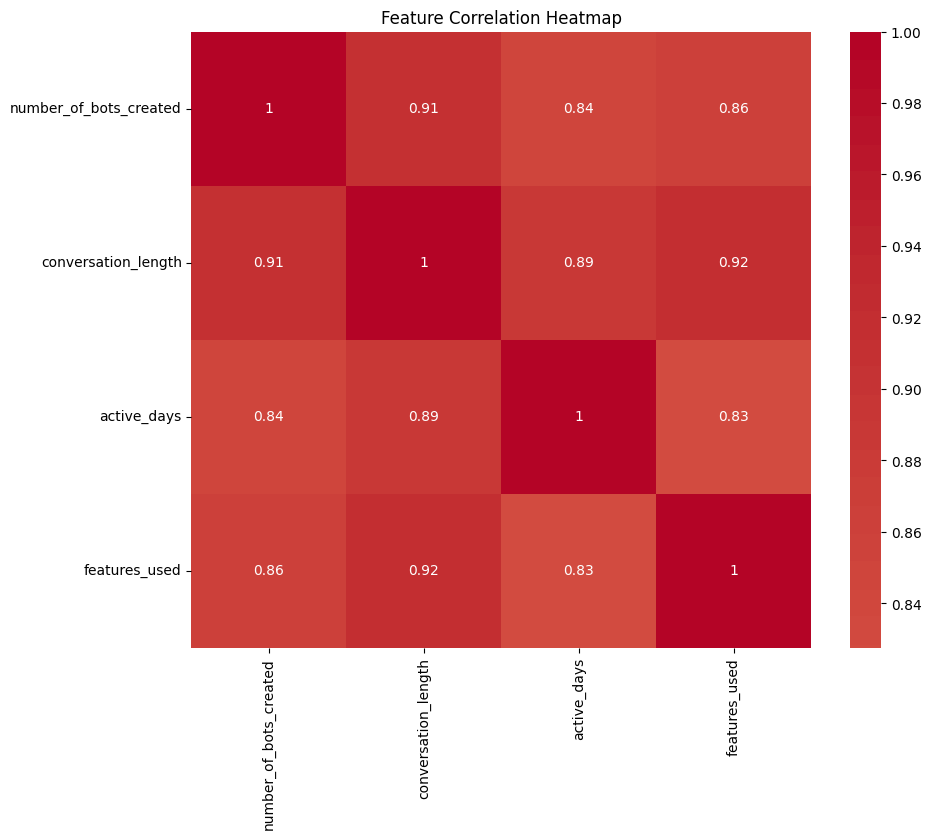

Features selected for clustering:
['number_of_bots_created', 'conversation_length', 'active_days', 'features_used']

Scaled data shape: (300, 4)


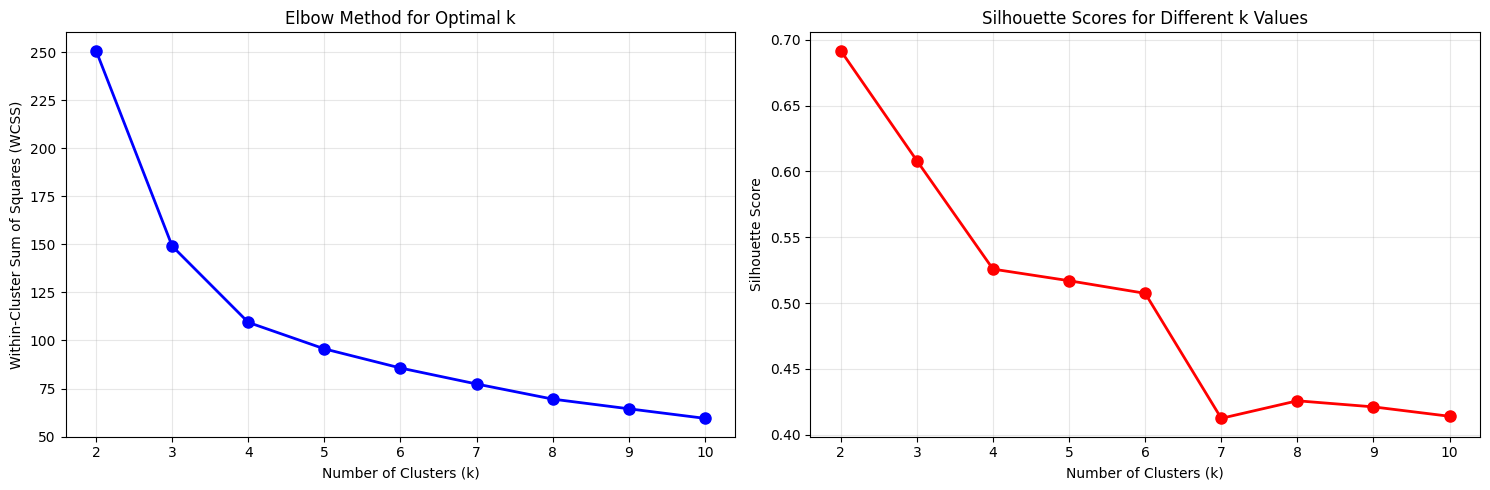

Selected number of clusters: 4
Silhouette score for k=4: 0.526
Cluster centers (original scale):


,number_of_bots_created,conversation_length,active_days,features_used,cluster
0,4.99,150.376707,19.28,4.00,0
1,15.14,393.236937,42.56,7.38,1
2,0.80,48.925306,5.07,1.55,2
3,15.82,413.898524,73.42,7.74,3


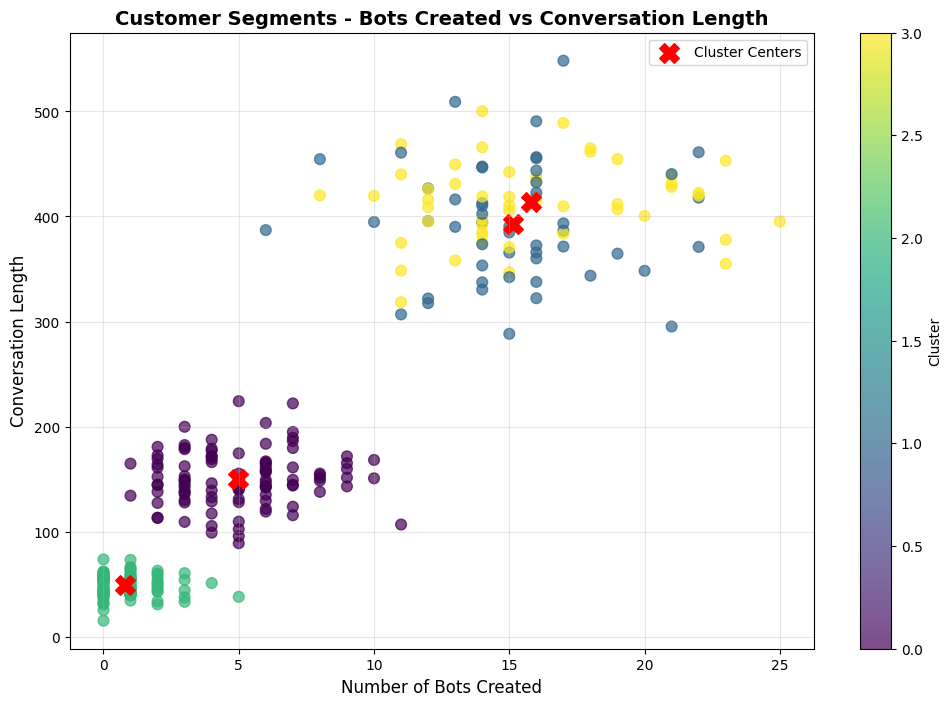

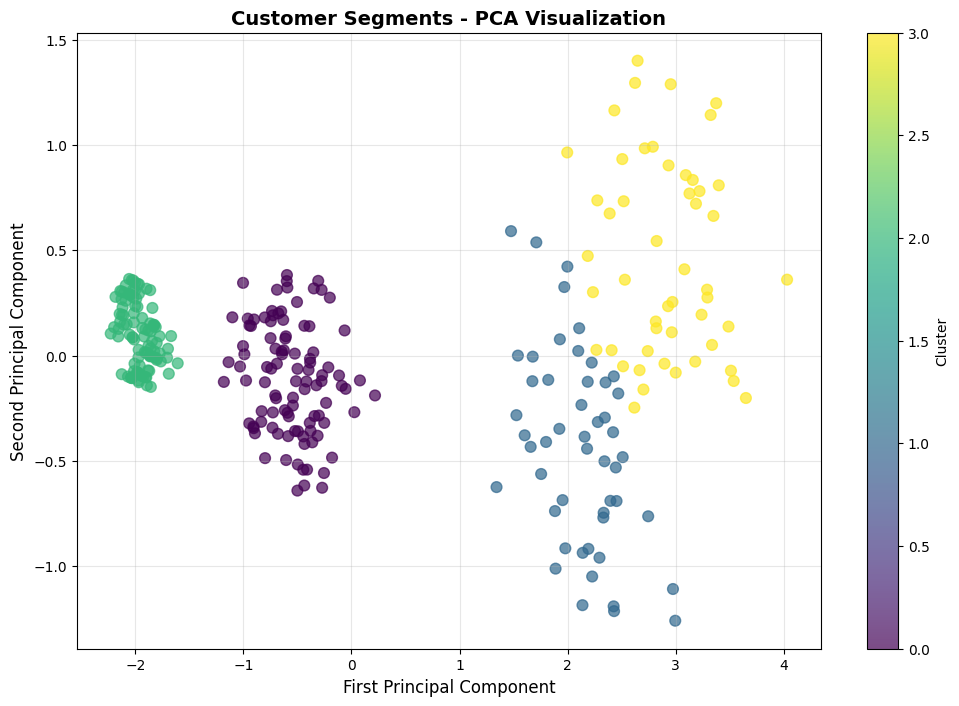

Cluster Summary Statistics:


number_of_bots_created                 conversation_length             \
                          mean       std count                mean        std   
cluster                                                                         
0                         4.99  2.236045   100          150.376707  26.084820   
1                        15.14  3.319761    50          393.236937  55.679266   
2                         0.80  1.015038   100           48.925306  10.230105   
3                        15.82  3.993311    50          413.898524  37.160257   

              active_days                 features_used                  
        count        mean       std count          mean       std count  
cluster                                                                  
0         100       19.28  5.479217   100          4.00  0.840875   100  
1          50       42.56  8.715831    50          7.38  1.243596    50  
2         100        5.07  2.712690   100          1.55  0.500000   100  
3          50       73.42  9.428766    50          7.74  1.174734    50

Detailed Cluster Profiles:


,number_of_bots_created,conversation_length,active_days,features_used,size,size_percentage
cluster,,,,,,
0,4.99,150.38,19.28,4.00,100,33.3
1,15.14,393.24,42.56,7.38,50,16.7
2,0.80,48.93,5.07,1.55,100,33.3
3,15.82,413.90,73.42,7.74,50,16.7


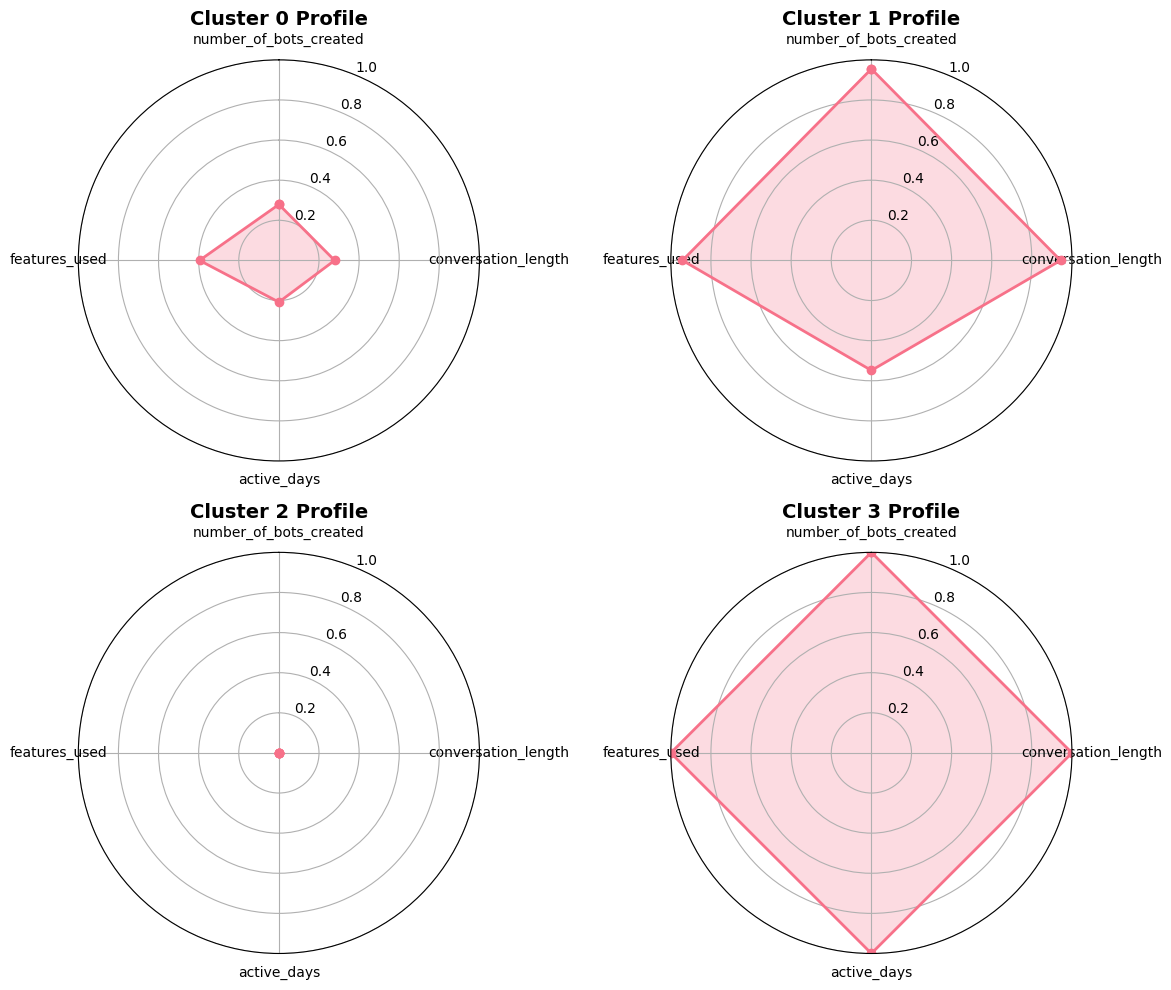

CUSTOMER SEGMENTATION ANALYSIS RESULTS

--- SEGMENT 0 ---
Segment Size: 100 customers (33.3%)
Average Bots Created: 5.0
Average Conversation Length: 150.4
Average Active Days: 19.3
Average Features Used: 4.0

--- SEGMENT 1 ---
Segment Size: 50 customers (16.7%)
Average Bots Created: 15.1
Average Conversation Length: 393.2
Average Active Days: 42.6
Average Features Used: 7.4

--- SEGMENT 2 ---
Segment Size: 100 customers (33.3%)
Average Bots Created: 0.8
Average Conversation Length: 48.9
Average Active Days: 5.1
Average Features Used: 1.6

--- SEGMENT 3 ---
Segment Size: 50 customers (16.7%)
Average Bots Created: 15.8
Average Conversation Length: 413.9
Average Active Days: 73.4
Average Features Used: 7.7

Results saved to 'customer_segmentation_results.csv'

ANALYSIS COMPLETE


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('default')
sns.set_palette("husl")

# %%
# Create mock customer behavior data
np.random.seed(42)
n_customers = 300

# Generate synthetic data representing different customer behaviors
data = {
    'customer_id': range(1, n_customers + 1),
    'number_of_bots_created': np.concatenate([
        np.random.poisson(1, 100),  # Low usage
        np.random.poisson(5, 100),  # Medium usage  
        np.random.poisson(15, 100)  # High usage
    ]),
    'conversation_length': np.concatenate([
        np.random.normal(50, 10, 100),   # Short conversations
        np.random.normal(150, 30, 100),  # Medium conversations
        np.random.normal(400, 50, 100)   # Long conversations
    ]),
    'active_days': np.concatenate([
        np.random.randint(1, 10, 100),    # Low activity
        np.random.randint(10, 30, 100),   # Medium activity
        np.random.randint(30, 90, 100)    # High activity
    ]),
    'features_used': np.concatenate([
        np.random.randint(1, 3, 100),     # Few features
        np.random.randint(3, 6, 100),     # Some features
        np.random.randint(6, 10, 100)     # Many features
    ])
}

# Create DataFrame
df = pd.DataFrame(data)
print("Dataset Overview:")
print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
display(df.head())

# %%
# Basic statistics and data exploration
print("Dataset Information:")
print(df.info())
print("\nDescriptive Statistics:")
print(df.describe())

# %%
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# %%
# Data Visualization - Feature Distributions
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot distributions
axes[0,0].hist(df['number_of_bots_created'], bins=20, alpha=0.7, color='skyblue')
axes[0,0].set_title('Distribution of Bots Created')
axes[0,0].set_xlabel('Number of Bots')
axes[0,0].set_ylabel('Frequency')

axes[0,1].hist(df['conversation_length'], bins=20, alpha=0.7, color='lightgreen')
axes[0,1].set_title('Distribution of Conversation Length')
axes[0,1].set_xlabel('Conversation Length')
axes[0,1].set_ylabel('Frequency')

axes[1,0].hist(df['active_days'], bins=20, alpha=0.7, color='salmon')
axes[1,0].set_title('Distribution of Active Days')
axes[1,0].set_xlabel('Active Days')
axes[1,0].set_ylabel('Frequency')

axes[1,1].hist(df['features_used'], bins=20, alpha=0.7, color='gold')
axes[1,1].set_title('Distribution of Features Used')
axes[1,1].set_xlabel('Features Used')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# %%
# Correlation heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = df[['number_of_bots_created', 'conversation_length', 'active_days', 'features_used']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

# %%
# Data Preprocessing
# Select features for clustering
features = ['number_of_bots_created', 'conversation_length', 'active_days', 'features_used']
X = df[features]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features selected for clustering:")
print(features)
print(f"\nScaled data shape: {X_scaled.shape}")

# %%
# Determine optimal number of clusters using Elbow Method
wcss = []  # Within-cluster sum of squares
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    
    # Calculate silhouette score
    if k > 1:  # Silhouette score requires at least 2 clusters
        score = silhouette_score(X_scaled, kmeans.labels_)
        silhouette_scores.append(score)

# %%
# Plot Elbow Method and Silhouette Scores
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Elbow curve
ax1.plot(k_range, wcss, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Within-Cluster Sum of Squares (WCSS)')
ax1.set_title('Elbow Method for Optimal k')
ax1.grid(True, alpha=0.3)

# Silhouette scores
ax2.plot(range(2, 11), silhouette_scores, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Scores for Different k Values')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# %%
# Based on the elbow method and silhouette scores, choose optimal k
optimal_k = 4  # You can adjust this based on the elbow point

print(f"Selected number of clusters: {optimal_k}")
print(f"Silhouette score for k={optimal_k}: {silhouette_scores[optimal_k-2]:.3f}")

# %%
# Perform K-means clustering with optimal k
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Add cluster centers to original scale for interpretation
cluster_centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
cluster_centers_df = pd.DataFrame(cluster_centers_original, columns=features)
cluster_centers_df['cluster'] = range(optimal_k)

print("Cluster centers (original scale):")
display(cluster_centers_df)

# %%
# Visualize clusters using the two most important features
plt.figure(figsize=(12, 8))

# Create scatter plot
scatter = plt.scatter(df['number_of_bots_created'], 
                     df['conversation_length'], 
                     c=df['cluster'], 
                     cmap='viridis', 
                     alpha=0.7, 
                     s=60)

plt.xlabel('Number of Bots Created', fontsize=12)
plt.ylabel('Conversation Length', fontsize=12)
plt.title('Customer Segments - Bots Created vs Conversation Length', fontsize=14, fontweight='bold')

# Add cluster centers
plt.scatter(cluster_centers_df['number_of_bots_created'], 
           cluster_centers_df['conversation_length'], 
           c='red', marker='X', s=200, label='Cluster Centers')

plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# %%
# Alternative visualization using PCA for better separation in 2D
from sklearn.decomposition import PCA

# Apply PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster'], cmap='viridis', alpha=0.7, s=60)
plt.xlabel('First Principal Component', fontsize=12)
plt.ylabel('Second Principal Component', fontsize=12)
plt.title('Customer Segments - PCA Visualization', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

# %%
# Analyze cluster characteristics
cluster_summary = df.groupby('cluster')[features].agg(['mean', 'std', 'count'])
print("Cluster Summary Statistics:")
display(cluster_summary)

# %%
# Create detailed cluster profiles
cluster_profiles = df.groupby('cluster')[features].mean().round(2)
cluster_profiles['size'] = df['cluster'].value_counts().sort_index()
cluster_profiles['size_percentage'] = (cluster_profiles['size'] / len(df) * 100).round(1)

print("Detailed Cluster Profiles:")
display(cluster_profiles)

# %%
# Visualize cluster characteristics using radar chart
from math import pi

# Normalize features for radar chart
def normalize_data(data):
    return (data - data.min()) / (data.max() - data.min())

normalized_profiles = cluster_profiles[features].apply(normalize_data, axis=0)

# Create radar chart
fig = plt.figure(figsize=(12, 10))
categories = features
N = len(categories)

# Create angles for radar chart
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

# Create subplot for each cluster
for cluster in range(optimal_k):
    ax = plt.subplot(2, 2, cluster+1, polar=True)
    
    values = normalized_profiles.loc[cluster].values.tolist()
    values += values[:1]
    
    ax.plot(angles, values, 'o-', linewidth=2, label=f'Cluster {cluster}')
    ax.fill(angles, values, alpha=0.25)
    
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)
    ax.set_ylim(0, 1)
    ax.set_title(f'Cluster {cluster} Profile', size=14, fontweight='bold')
    ax.grid(True)

plt.tight_layout()
plt.show()

# %%
# Final cluster analysis and business interpretation
print("="*60)
print("CUSTOMER SEGMENTATION ANALYSIS RESULTS")
print("="*60)

for cluster in range(optimal_k):
    cluster_data = df[df['cluster'] == cluster]
    print(f"\n--- SEGMENT {cluster} ---")
    print(f"Segment Size: {len(cluster_data)} customers ({len(cluster_data)/len(df)*100:.1f}%)")
    print(f"Average Bots Created: {cluster_data['number_of_bots_created'].mean():.1f}")
    print(f"Average Conversation Length: {cluster_data['conversation_length'].mean():.1f}")
    print(f"Average Active Days: {cluster_data['active_days'].mean():.1f}")
    print(f"Average Features Used: {cluster_data['features_used'].mean():.1f}")

# %%
# Save the results
df.to_csv('customer_segmentation_results.csv', index=False)
print("\nResults saved to 'customer_segmentation_results.csv'")

print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)